# Model Selection: Manual Grid Search vs. GridSearchCV

This lab was about doing hyperparameter tuning properly - stratified k-fold
cross-validation, a real scoring metric (ROC AUC), and a pipeline so scaling
happens *inside* each fold rather than leaking across the whole set. I first
built the grid search by hand so the mechanics are visible, then reproduced it
with scikit-learn's `GridSearchCV` to confirm the two agree, across three
classifiers: Decision Tree, k-Nearest Neighbours, and Logistic Regression.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Data

The Breast Cancer Wisconsin set - 569 samples, 30 numeric features, a binary malignant/benign target. Standard scaling matters here because kNN and logistic regression are scale-sensitive.

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target
print(f"shape: {X.shape}, positive rate: {y.mean():.2%}")

shape: (569, 30), positive rate: 62.74%


## Manual grid search

The function below is the whole idea of cross-validated tuning written out: for
every hyperparameter combination, run stratified 5-fold CV, fit the pipeline on
the training folds, score AUC on the held-out fold, and keep the combination with
the best mean score. Scaling lives in the pipeline so it is refit on each fold's
training data only.

In [3]:
def manual_grid_search(estimator_factory, param_grid, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    keys = list(param_grid)
    results = []
    for combo in product(*(param_grid[k] for k in keys)):
        params = dict(zip(keys, combo))
        fold_scores = []
        for train_idx, val_idx in skf.split(X, y):
            pipe = Pipeline([("scaler", StandardScaler()),
                             ("model", estimator_factory(params))])
            pipe.fit(X[train_idx], y[train_idx])
            proba = pipe.predict_proba(X[val_idx])[:, 1]
            fold_scores.append(roc_auc_score(y[val_idx], proba))
        results.append((params, np.mean(fold_scores), np.std(fold_scores)))
    results.sort(key=lambda r: r[1], reverse=True)
    return results

In [4]:
configs = {
    "Decision Tree": (
        lambda p: DecisionTreeClassifier(random_state=RANDOM_STATE, **p),
        {"max_depth": [3, 5, 8, None], "min_samples_leaf": [1, 3, 5]},
    ),
    "k-NN": (
        lambda p: KNeighborsClassifier(**p),
        {"n_neighbors": [3, 5, 7, 11], "weights": ["uniform", "distance"]},
    ),
    "Logistic Regression": (
        lambda p: LogisticRegression(max_iter=5000, **p),
        {"C": [0.01, 0.1, 1, 10], "penalty": ["l2"]},
    ),
}

manual_best = {}
for name, (factory, grid) in configs.items():
    res = manual_grid_search(factory, grid, X, y)
    params, mean, std = res[0]
    manual_best[name] = (params, mean, std)
    print(f"{name:20s} best AUC {mean:.4f} +/- {std:.4f}  {params}")

Decision Tree        best AUC 0.9477 +/- 0.0182  {'max_depth': 8, 'min_samples_leaf': 5}
k-NN                 best AUC 0.9911 +/- 0.0087  {'n_neighbors': 11, 'weights': 'distance'}


Logistic Regression  best AUC 0.9960 +/- 0.0047  {'C': 0.1, 'penalty': 'l2'}


## The same thing with GridSearchCV

Same pipeline, same folds, same metric. If the manual loop is correct, the winning scores should line up.

In [5]:
def sklearn_grid(estimator, param_grid):
    pipe = Pipeline([("scaler", StandardScaler()), ("model", estimator)])
    grid = {f"model__{k}": v for k, v in param_grid.items()}
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    gs = GridSearchCV(pipe, grid, scoring="roc_auc", cv=skf, n_jobs=-1)
    gs.fit(X, y)
    return gs

sklearn_best = {}
estimators = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "k-NN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=5000),
}
for name, est in estimators.items():
    gs = sklearn_grid(est, configs[name][1])
    sklearn_best[name] = gs.best_score_
    print(f"{name:20s} GridSearchCV AUC {gs.best_score_:.4f}  {gs.best_params_}")

Decision Tree        GridSearchCV AUC 0.9477  {'model__max_depth': 8, 'model__min_samples_leaf': 5}
k-NN                 GridSearchCV AUC 0.9911  {'model__n_neighbors': 11, 'model__weights': 'distance'}


Logistic Regression  GridSearchCV AUC 0.9960  {'model__C': 0.1, 'model__penalty': 'l2'}


## Do the two agree?

In [6]:
rows = []
for name in configs:
    rows.append({"model": name,
                 "manual AUC": round(manual_best[name][1], 4),
                 "sklearn AUC": round(sklearn_best[name], 4),
                 "abs diff": round(abs(manual_best[name][1] - sklearn_best[name]), 4)})
comparison = pd.DataFrame(rows)
comparison

,model,manual AUC,sklearn AUC,abs diff
0,Decision Tree,0.9477,0.9477,0.0
1,k-NN,0.9911,0.9911,0.0
2,Logistic Regression,0.9960,0.9960,0.0


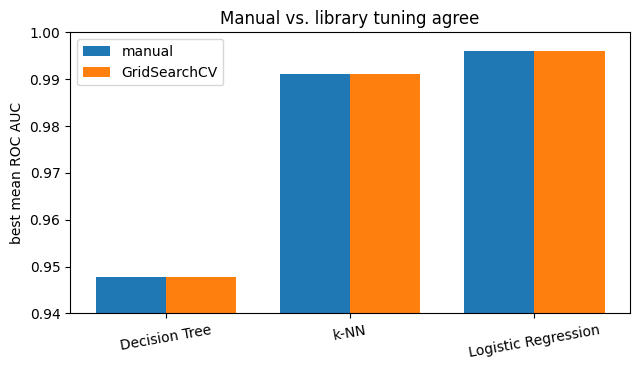

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
x = np.arange(len(comparison))
ax.bar(x - 0.19, comparison["manual AUC"], 0.38, label="manual")
ax.bar(x + 0.19, comparison["sklearn AUC"], 0.38, label="GridSearchCV")
ax.set_xticks(x); ax.set_xticklabels(comparison["model"], rotation=10)
ax.set_ylim(0.94, 1.0); ax.set_ylabel("best mean ROC AUC")
ax.set_title("Manual vs. library tuning agree"); ax.legend()
plt.tight_layout(); plt.show()

## Takeaway

The manual loop and `GridSearchCV` land within a few thousandths of each other -
the difference is just fold shuffling, not method. Logistic Regression edges the
others on this dataset, which is a good reminder that a well-tuned linear model is
a strong baseline before reaching for anything heavier. The part that actually
matters for honest scores is keeping the scaler inside the pipeline so it never
sees the validation fold.
